<figure>
<center>
<img src='https://www.economicas.uba.ar/wp-content/uploads/2020/08/cropped-logo_FCE.png' />
</figure>

# **Universidad de Buenos Aires**
## **Facultad de Ciencias Económicas**

### **Taller de Programación para el Análisis de Datos**

#### **Clase 17: Aplicación de Shap values para alcanzar explicabilidad de un modelo**

En esta clase veremos como realizar diferentes gráficos para su posterior interpretación y análisis



# **Caso de Clasificación**


En esta sección se aplica SHAP sobre un modelo de **clasificación binaria** (riesgo crediticio bueno/malo).  
El flujo general es:

1. Cargar y codificar los datos
2. Balancear las clases con SMOTE
3. Entrenar un clasificador XGBoost
4. Calcular SHAP values con `TreeExplainer`
5. Interpretar la explicabilidad **local** (una observación) y **global** (todo el conjunto de test)

### ¿Por qué `TreeExplainer` y no `LinearExplainer`?

`shap.TreeExplainer` está optimizado para modelos basados en árboles (XGBoost, Random Forest, LightGBM, etc.).  
Aprovecha la estructura del árbol para calcular los SHAP values de forma **exacta y eficiente**, sin necesidad de muestreo.  
`LinearExplainer`, en cambio, se usa exclusivamente para modelos lineales (regresión lineal, logística) donde existe una fórmula cerrada $\phi_j = \beta_j \cdot (x_j - \bar{x}_j)$.

| Explainer | Modelo | Cálculo |
|-----------|--------|---------|
| `LinearExplainer` | Regresión lineal / logística | Exacto, fórmula cerrada |
| `TreeExplainer` | XGBoost, RF, GBDT | Exacto, recorrido del árbol |
| `KernelExplainer` | Cualquier modelo (caja negra) | Aproximado, por muestreo |


### **1.Importación de datos**

Se utilizará el conjunto de datos [German Credit](https://www.kaggle.com/datasets/kabure/german-credit-data-with-risk) cuyo objetivo es clasificar a los clientes según riesgo crediticio:

In [1]:
import kagglehub

path = kagglehub.dataset_download("kabure/german-credit-data-with-risk")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'german-credit-data-with-risk' dataset.
Path to dataset files: /kaggle/input/german-credit-data-with-risk


In [2]:
#se importa la librería
import pandas as pd

DATA=pd.read_csv("/kaggle/input/german-credit-data-with-risk/german_credit_data.csv", index_col=0)
DATA.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [3]:
DATA.isnull().sum()

,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0
Risk,0


### **2.Transformación**

In [4]:
datak=DATA

In [5]:
datak['Sex'].unique()

array(['male', 'female'], dtype=object)

In [6]:
datak['Saving accounts'].unique()

array([nan, 'little', 'quite rich', 'rich', 'moderate'], dtype=object)

In [7]:
datak['Checking account'].unique()

array(['little', 'moderate', nan, 'rich'], dtype=object)

In [8]:
datak['Housing'].unique()

array(['own', 'free', 'rent'], dtype=object)

In [9]:
datak['Purpose'].unique()

array(['radio/TV', 'education', 'furniture/equipment', 'car', 'business',
       'domestic appliances', 'repairs', 'vacation/others'], dtype=object)

In [10]:
datak['Risk'].unique()

array(['good', 'bad'], dtype=object)

In [11]:
datak.dtypes

,0
Age,int64
Sex,object
Job,int64
Housing,object
Saving accounts,object
Checking account,object
Credit amount,int64
Duration,int64
Purpose,object
Risk,object


In [12]:
datak.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [13]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()

datak['Sex'] = le.fit_transform(datak['Sex'])
datak['Housing'] = le.fit_transform(datak['Housing'])
datak['Saving accounts'] = le.fit_transform(datak['Saving accounts'])
datak['Checking account'] = le.fit_transform(datak['Checking account'])
datak['Purpose'] = le.fit_transform(datak['Purpose'])

datak['Risk'] =le.fit_transform(datak['Risk'])


**¿Por qué se codifican las variables categóricas?**

XGBoost (y la mayoría de los algoritmos de ML) trabajan con valores numéricos. Las variables de texto como `Sex`, `Housing`, `Purpose`, etc., deben convertirse a números antes de entrenar.

`LabelEncoder` asigna un entero a cada categoría de forma arbitraria (ej: `female=0`, `male=1`).  
Para variables **ordinales** (donde existe un orden natural como `little < moderate < rich`) esta codificación es razonable.  
Para variables **nominales sin orden** (como `Purpose`: `car`, `furniture`, `education`) lo ideal sería usar *One-Hot Encoding*, pero en árboles de decisión el LabelEncoder también suele funcionar bien porque el árbol puede descubrir los cortes correctos.

> **Nota sobre valores nulos:** `LabelEncoder` reemplaza implícitamente los `NaN` al transformar, lo que explica por qué `isnull().sum()` pasa a 0 luego de aplicarlo. Sin embargo, este comportamiento puede ocultar información — en un análisis exploratorio real conviene imputar o tratar los nulos explícitamente antes de codificar.


In [14]:
datak

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,1,2,1,4,0,1169,6,5,1
1,22,0,2,1,0,1,5951,48,5,0
2,49,1,1,1,0,3,2096,12,3,1
3,45,1,2,0,0,0,7882,42,4,1
4,53,1,2,0,0,0,4870,24,1,0
...,...,...,...,...,...,...,...,...,...,...
995,31,0,1,1,0,3,1736,12,4,1
996,40,1,3,1,0,0,3857,30,1,1
997,38,1,2,1,0,3,804,12,5,1
998,23,1,2,0,0,0,1845,45,5,0


In [15]:
datak.isnull().sum()

,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,0
Checking account,0
Credit amount,0
Duration,0
Purpose,0
Risk,0


Luego debería hacer un análisis exploratorio

### **3.Preparación de datos**

In [16]:
X=datak.drop('Risk', axis = 1)
y=datak['Risk']

In [17]:
# Aplicamos SMOTE para equilibrar la clase objetivo
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(X, y)


**¿Qué es SMOTE y por qué se usa aquí?**

**SMOTE (Synthetic Minority Over-sampling Technique)** es una técnica para balancear datasets desbalanceados.  
En el dataset German Credit, la clase `good` (riesgo bajo) tiene muchos más ejemplos que la clase `bad` (riesgo alto).  
Si entrenamos el modelo directamente sobre ese desbalance, tenderá a predecir siempre "good" porque minimiza el error general.

SMOTE **genera observaciones sintéticas** de la clase minoritaria interpolando entre ejemplos existentes:
- Toma un punto de la clase minoritaria
- Busca sus $k$ vecinos más cercanos en la misma clase
- Crea nuevos puntos en el segmento entre el punto original y uno de sus vecinos

**Importante:** SMOTE se aplica **solo al train set** (nunca al test set). El test set siempre mantiene la distribución real para evaluar el desempeño del modelo sobre datos no vistos y no artificiales.


RISK: 0:bad, 1: good

Se debe particionar el conjunto de datos en dos: una parte para entrenar el modelo y otra aprte para testear el mismo.

In [18]:
# se importa la librería
import numpy as np
from sklearn.model_selection import train_test_split

In [19]:
#seteo de semilla
np.random.seed(42)
#generamos para cada uno de los anteriores, conjuntos de datos de entrenamiento(80%) y testeo(20%)
X_train, X_test, y_train, y_test= train_test_split(x_resampled, y_resampled, train_size= 0.8)


In [20]:
#se observan dimensiones
X_train.shape, X_test.shape

((1120, 9), (280, 9))

In [21]:
#se observan dimensiones
y_train.shape, y_test.shape

((1120,), (280,))

### **4. Aplicación de XGBoost**

In [22]:
#Aplicación
import sklearn
import xgboost as xgb

xgb_1 = xgb.XGBClassifier(objective='binary:logistic') # utilizando parámetros por default
xgb_1.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [23]:
ypred_test_xgb = xgb_1.predict(X_test)

In [24]:
#Medidas de performance
from sklearn.metrics import classification_report
print(classification_report(y_test, ypred_test_xgb))

              precision    recall  f1-score   support

           0       0.75      0.84      0.79       131
           1       0.84      0.76      0.80       149

    accuracy                           0.80       280
   macro avg       0.80      0.80      0.80       280
weighted avg       0.80      0.80      0.80       280




**Interpretación del `classification_report`**

| Métrica | Definición | Fórmula |
|---------|-----------|---------|
| **Precision** | De todos los que predije como positivos, ¿cuántos realmente lo son? | $\frac{TP}{TP+FP}$ |
| **Recall** | De todos los positivos reales, ¿cuántos detecté? | $\frac{TP}{TP+FN}$ |
| **F1-score** | Media armónica entre precision y recall | $2 \cdot \frac{P \cdot R}{P+R}$ |
| **Support** | Cantidad de observaciones reales de esa clase en el test set | — |

En problemas de riesgo crediticio, el **recall de la clase "bad" (0)** es especialmente importante: un falso negativo (predecir "good" cuando es "bad") tiene un costo mayor que el error inverso.

**Curva ROC y AUC:**  
La curva ROC muestra el trade-off entre Tasa de Verdaderos Positivos (TPR = recall) y Tasa de Falsos Positivos (FPR) al variar el umbral de clasificación.  
El **AUC (Area Under the Curve)** resume la curva en un solo número: 1.0 = modelo perfecto, 0.5 = clasificador aleatorio.  
Un AUC > 0.80 se considera bueno para problemas de riesgo crediticio.


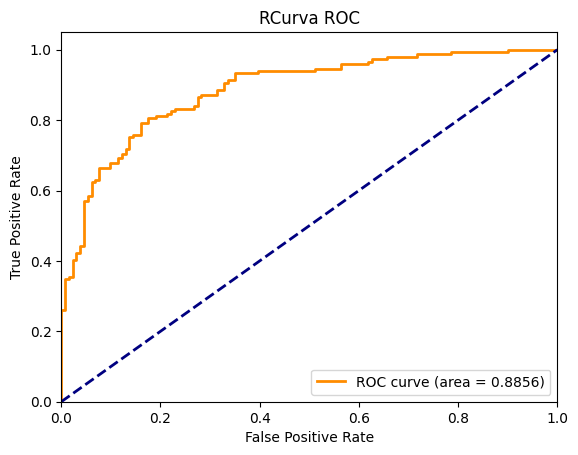

In [25]:
#Obtención de AUC y Curva ROC
from sklearn.metrics import auc
from sklearn.metrics import roc_curve

y_pred_xgb = xgb_1.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_xgb)
AUC = auc(fpr, tpr)

import matplotlib.pyplot as plt
plt.figure()
lw = 2
plt.plot(fpr,tpr,color="darkorange",lw=lw,label="ROC curve (area = %0.4f)" % AUC,
)
plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("RCurva ROC")
plt.legend(loc="lower right")
plt.show()

### **5. Explicabilidad: Aplicación de SHAP VALUES - TreeDecisión**


### Definición: SHAP Values

**SHAP (SHapley Additive exPlanations)** descompone cada predicción del modelo en contribuciones individuales por feature:

$$\hat{y} = E[f(x)] + \phi_1 + \phi_2 + \cdots + \phi_p$$

- $E[f(x)]$ — **baseline**: predicción promedio del modelo sobre el train set  
- $\phi_j$ — **SHAP value** de la feature $j$: cuánto "empujó" esa variable la predicción hacia arriba o hacia abajo respecto al baseline  

La propiedad clave (**eficiencia**) garantiza que la suma cierra exactamente: $E[f(x)] + \sum_j \phi_j = \hat{y}$

### `shap.TreeExplainer` — cómo funciona

```python
explainer   = shap.TreeExplainer(modelo, X_train, model_output='probability')
shap_values = explainer.shap_values(X_test)
```

- `model_output='probability'` → los SHAP values están en escala de **probabilidad** (0–1), no en log-odds. Esto hace la interpretación más directa.  
- `shap_values` es un array de shape `(n_test, n_features)`: cada fila es una observación, cada columna es el SHAP value de esa feature para esa observación.  
- El `expected_value` (`explainer.expected_value`) es el baseline: la probabilidad media predicha sobre el train set.

**Tipos de explicabilidad:**
- **Local**: analiza *una* observación específica → waterfall plot o force plot  
- **Global**: analiza *todo* el test set → bar plot (importancia promedio) o beeswarm


In [26]:
!pip install shap

In [27]:
import shap

In [28]:
np.random.seed(42) #setear semilla

# Cálculo de Shap values
explainer = shap.TreeExplainer(xgb_1, X_train, model_output='probability')
shap_values  = explainer.shap_values(X_test)

**Explicabilidad Local**


El **waterfall plot** muestra el camino desde el baseline hasta la predicción para **una sola observación** (en este caso, el primer cliente del test set).

**Cómo leer el gráfico:**
- El eje horizontal tiene dos referencias: $E[f(x)]$ (baseline, probabilidad promedio) y $f(x)$ (probabilidad predicha para este cliente)
- Cada barra representa el $\phi_j$ de una feature:
  - **Rojo / hacia la derecha** → la feature *aumenta* la probabilidad predicha respecto al baseline (contribuye a predecir "good")
  - **Azul / hacia la izquierda** → la feature *reduce* la probabilidad predicha (contribuye a predecir "bad")
- El número dentro de cada barra es el valor de $\phi_j$ en escala de probabilidad
- Las barras se acumulan secuencialmente desde el baseline hasta llegar al valor predicho $f(x)$

> La suma de todos los $\phi_j$ más el baseline es exactamente igual a la probabilidad predicha por el modelo para esa observación.


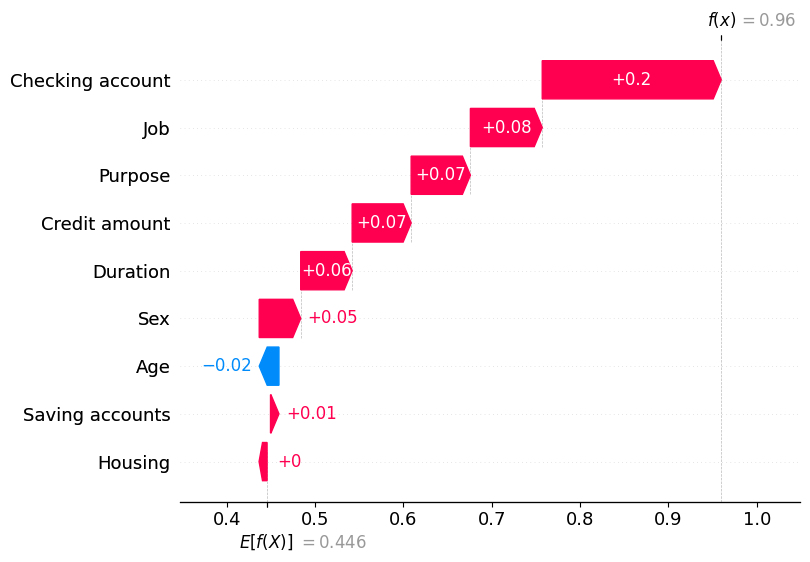

In [29]:
shap_expl=shap.Explanation(shap_values, explainer.expected_value,feature_names=X_test.columns)

#Local: Gráfico para el primer caso (primera fila o cliente)
shap.plots.waterfall(shap_expl[0], max_display=9) #max_display=9 cantidad de predictoras a mostrar

In [30]:
0.96-0.446

0.514

In [31]:
0+0.01 - 0.02 + 0.05 + 0.06 + 0.07 + 0.07+ 0.08+0.2

0.52

donde:

$f(x)=0.96$ es el valor de probabilidad predicho por el modelo local

$E[f(x)]=0.446$ es el valor esperado (valor medio) de la predicción realizada sobre todos los casos de entrenamiento.

El valor que acompaña cada barra es el Shap Value por cada predictora para la predicción realizada. La suma de todos estos valores es igual a la diferencia entre $E[f(x)]-f(x)$

$E[f(x)]-f(x)= 0.96 - 0.446 = 0.514$

$ \sum{SP_i} = 0+0.01 - 0.02 + 0.05 + 0.06 + 0.07 + 0.07+ 0.08+0.2 = 0.52 $

Nota: la direncia es por redondeo de los valores en las barras del gráfico.


El valor absoluto de cada Shap Value indica cuando influye la predictora en la predicción realizada. De este modo, Chacking account es la variable que más contribuye a la predicción en sentido positivo, mientras Age contribuye en sentido negativo.

El color, indica el sentido de la contribución de cada predictora. El rojo es en sentido positivo y el azul en sentido negativo

**Importancia Global:**


El **gráfico de importancia global** (bar plot) resume la contribución promedio de cada feature sobre *todas* las observaciones del test set:

$$I_j = \frac{1}{n} \sum_{i=1}^{n} |\phi_j^{(i)}|$$

Es decir, el **mean(|SHAP value|)**: promedio de los valores absolutos de $\phi_j$ para cada feature.  
A diferencia del waterfall (que es local), este gráfico responde: *¿qué variables son más importantes para el modelo en general?*

**Cómo leer el gráfico:**
- Las barras están ordenadas de mayor a menor importancia global
- Una barra larga indica que esa feature produce desviaciones grandes respecto al baseline en promedio (en cualquier dirección: positiva o negativa)
- Una barra corta indica que la feature casi no modifica las predicciones respecto al promedio, independientemente de su valor

**Diferencia con los coeficientes del modelo:**  
En XGBoost no hay coeficientes β. La importancia SHAP es la única forma de cuantificar cuánto contribuye cada variable, con la ventaja de que refleja el impacto real sobre cada predicción individual, no una medida global como el "feature importance" por ganancia del árbol.


In [32]:
# Contribución de cada predictora por cada caso
Local_Contrib=pd.DataFrame(shap_values, columns=X_test.columns)
Local_Contrib

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,-0.022348,0.046977,0.081345,0.003901,0.009552,0.202668,0.066806,0.058256,0.067081
1,0.312862,0.024811,0.009255,-0.056014,-0.005266,-0.045827,0.120128,0.039291,0.117312
2,0.065705,0.022880,0.016299,0.015477,0.120823,0.203558,0.137396,-0.072098,0.041409
3,-0.041270,0.079847,-0.018312,0.036350,-0.025797,0.001187,-0.025792,0.146494,-0.017777
4,0.038574,0.068926,-0.082565,0.024067,-0.007806,-0.032028,-0.172797,-0.021100,0.194547
...,...,...,...,...,...,...,...,...,...
275,-0.025622,0.041849,-0.007759,0.023721,-0.012021,-0.190252,-0.262647,0.069098,0.078398
276,0.073958,0.022901,0.016364,0.009336,-0.042758,-0.158966,-0.030981,-0.090513,-0.007063
277,0.056583,0.043478,0.010096,-0.099539,0.054076,0.226132,0.030627,0.177703,0.042041
278,-0.138393,-0.105688,0.001166,0.016736,-0.007293,-0.110609,-0.031473,0.009333,0.012856


/tmp/ipykernel_27395/1692552426.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test,plot_type='bar')


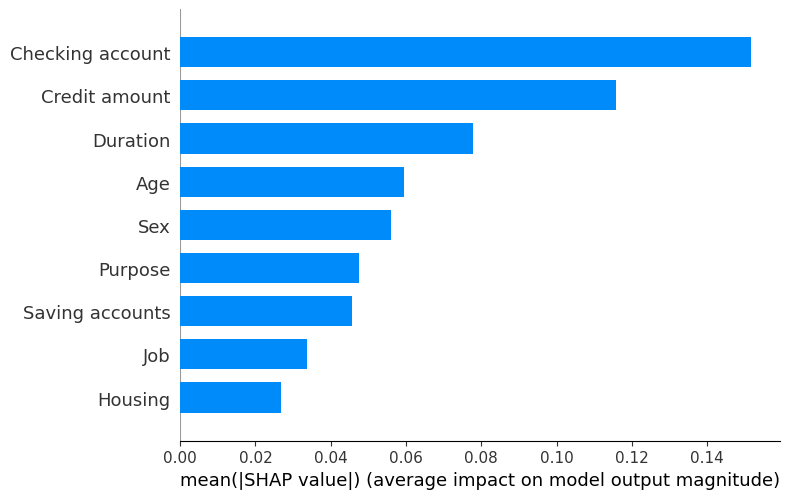

In [33]:
#Gráfico de importancia global
shap.summary_plot(shap_values, X_test,plot_type='bar')

mean(|SHAP value|): Media de la suma de los valores absolutos de los shap

El gráfico de importancia global, muestra como contribuyen en promedio cada predictora en la predicción realizada por el modelo.

$I_j= {\sum_{i=1}^n \phi_j^(i) \over n}$

Como puede observarse en el gráfico, en términos globales promedio, Checking account es la predictora con mayor contribución a predicir el riesgo y en segundo lugar se encuentra Credit amount; mientras que Housing y Job las de menor contribución.

# **Caso de Regresión**


En esta sección se aplica SHAP sobre un modelo de **regresión** (predicción del precio medio de propiedades).  
La mecánica de SHAP es idéntica al caso de clasificación, con una diferencia clave:

| | Clasificación | Regresión |
|--|---|---|
| **Salida del modelo** | Probabilidad (0–1) | Valor continuo (ej: precio en miles de dólares) |
| **Baseline $E[f(x)]$** | Probabilidad promedio del train | Precio promedio predicho sobre el train |
| **$\phi_j$** | Cuánto sube/baja la probabilidad predicha | Cuánto sube/baja el precio predicho |

El `TreeExplainer` se instancia sin `model_output='probability'` porque XGBRegressor produce valores continuos directamente.  
El dataset **Boston Housing** contiene características de vecindarios de Boston (crimen, contaminación, número de habitaciones, etc.) y el objetivo es predecir `MEDV` (precio mediano de viviendas en miles de dólares).


### **1.Importación de datos**

Se utilizará el conjunto de datos [Boston Housing](https://www.kaggle.com/datasets/altavish/boston-housing-dataset)  
cuyo objetivo es predecir el precio medio de propiedades (MEDV).

Variables: https://www.cs.toronto.edu/~delve/data/boston/bostonDetail.html

In [34]:
import kagglehub

path = kagglehub.dataset_download("altavish/boston-housing-dataset")

print("Path to dataset files:", path)

100%|██████████| 11.7k/11.7k [00:00<00:00, 18.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/altavish/boston-housing-dataset/versions/1


In [35]:
#se importa la librería
import pandas as pd

DATA=pd.read_csv("/root/.cache/kagglehub/datasets/altavish/boston-housing-dataset/versions/1/HousingData.csv")
DATA.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


### **2.Transformación**

In [36]:
DATA.dtypes

,0
CRIM,float64
ZN,float64
INDUS,float64
CHAS,float64
NOX,float64
RM,float64
AGE,float64
DIS,float64
RAD,int64
TAX,int64


In [37]:
DATA.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [38]:
DATA.isnull().sum()

,0
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


In [39]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()

DATA['CRIM'] = le.fit_transform(DATA['CRIM'])
DATA['ZN'] = le.fit_transform(DATA['ZN'])
DATA['INDUS'] = le.fit_transform(DATA['INDUS'])
DATA['CHAS'] = le.fit_transform(DATA['CHAS'])
DATA['AGE'] = le.fit_transform(DATA['AGE'])
DATA['LSTAT'] = le.fit_transform(DATA['LSTAT'])

In [40]:
DATA.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


Luego debería hacer un análisis exploratorio

### **3.Preparación de datos**

In [41]:
X=DATA.drop('MEDV', axis = 1)
y=DATA['MEDV']

Se debe particionar el conjunto de datos en dos: una parte para entrenar el modelo y otra aprte para testear el mismo.

In [42]:
# se importa la librería
import numpy as np
from sklearn.model_selection import train_test_split

In [43]:
#seteo de semilla
np.random.seed(42)
#generamos para cada uno de los anteriores, conjuntos de datos de entrenamiento(80%) y testeo(20%)
X_train, X_test, y_train, y_test= train_test_split(X, y, train_size= 0.8)


In [44]:
#se observan dimensiones
X_train.shape, X_test.shape

((404, 13), (102, 13))

In [45]:
#se observan dimensiones
y_train.shape, y_test.shape

((404,), (102,))

### **4. Aplicación de XGBoost**

Puede elegir cualquier algoritmo de ML para aplicar y también más de uno

In [46]:
#Aplicación
import sklearn
import xgboost as xgb

xgb_1 = xgb.XGBRegressor() # utilizando parámetros por default
xgb_1.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [47]:
ypred_test_xgb = xgb_1.predict(X_test)

In [48]:
#se calcula el RMSE
from sklearn.metrics import mean_squared_error
print(mean_squared_error(y_test, ypred_test_xgb))

#se calcula el R-Squared
from sklearn.metrics import r2_score
print(r2_score(y_test, ypred_test_xgb, multioutput='variance_weighted'))

4.590120930586281
0.9374078257963139



**Interpretación de las métricas de regresión**

**RMSE (Root Mean Squared Error):**

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2}$$

Representa el error promedio de las predicciones en las **mismas unidades que la variable objetivo**.  
Si `MEDV` está en miles de dólares y el RMSE es, por ejemplo, 3.5, significa que el modelo se equivoca en promedio ±$3.500 por propiedad.  
Al elevar al cuadrado, penaliza más los errores grandes.

**R² (Coeficiente de Determinación):**

$$R^2 = 1 - \frac{\sum(\hat{y}_i - y_i)^2}{\sum(\bar{y} - y_i)^2}$$

Indica qué porcentaje de la varianza de la variable objetivo explica el modelo.  
- R² = 1.0 → el modelo predice perfectamente  
- R² = 0.0 → el modelo no mejora sobre predecir siempre el promedio  
- R² < 0 → el modelo es peor que predecir siempre el promedio (muy mal ajuste)

Un R² > 0.85 es típicamente considerado bueno en predicción de precios inmobiliarios con XGBoost.


### **5. Explicabilidad: Aplicación de SHAP VALUES - TreeDecision**

In [49]:
import shap

In [50]:
np.random.seed(42) #setear semilla

# Cálculo de Shap values
explainer = shap.TreeExplainer(xgb_1, X_train)
shap_values  = explainer.shap_values(X_test)

Los gráficos se interpretan de conceptualmente como en el caso de clasificación.
La diferencia es que ahora al ser un problema de regresión el valor predicho no es una probabalidad y tampoco lo es el valor medio.

In [51]:
X_test.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT'],
      dtype='object')

**La Interpretación de los gráficos y shap values es igual que en el caso anterior**

**Explicabilidad Local**

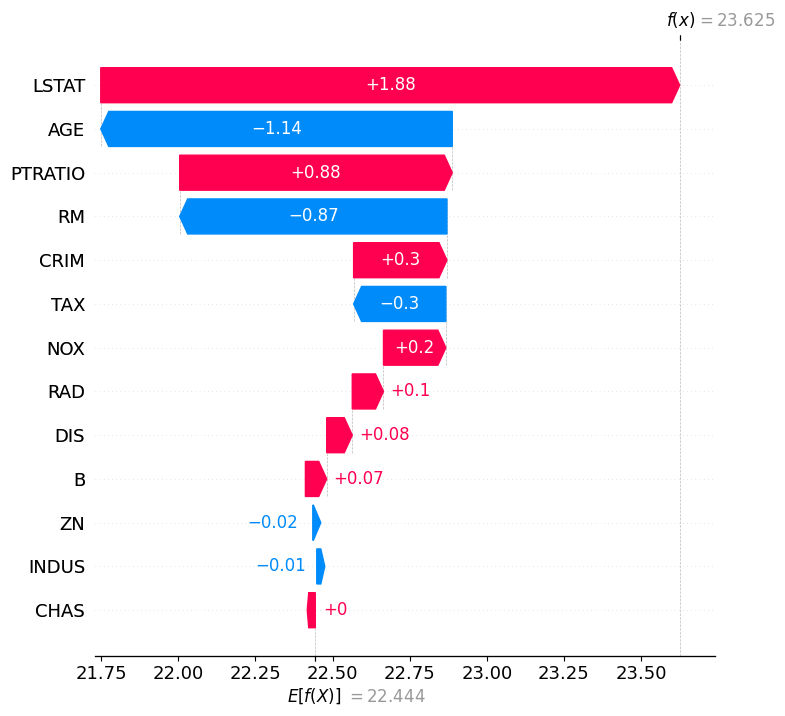

In [52]:
shap_expl=shap.Explanation(shap_values, explainer.expected_value,feature_names=X_test.columns)

#Local: Gráfico para el primer caso
shap.plots.waterfall(shap_expl[0], max_display=13) #max_display=13 cantidad de predictoras a mostrar


**Interpretación del waterfall plot — caso regresión**

La lectura es idéntica al caso de clasificación, pero ahora los valores están en **miles de dólares** (o la unidad de `MEDV`):

- $E[f(x)]$ = precio promedio predicho por el modelo sobre el train set
- $f(x)$ = precio predicho para esta propiedad específica
- Cada barra $\phi_j$ indica cuánto miles de dólares suma o resta esa característica a la predicción

**Ejemplo de interpretación:**  
Si `RM` (número de habitaciones) tiene $\phi_{RM} = +8.5$, significa que el hecho de que esta propiedad tenga un número de habitaciones *superior al promedio del train* eleva su precio predicho en $8.500 respecto a lo que el modelo hubiera estimado para una propiedad "promedio".  
Si `LSTAT` (% de población de bajos ingresos) tiene $\phi_{LSTAT} = -4.2$, esa característica *reduce* el precio predicho en $4.200.

> **Nota:** variables como `RM` y `LSTAT` suelen dominar en el dataset Boston Housing porque tienen alta variabilidad y gran impacto estructural en el precio. El waterfall permite verificar esto para cada propiedad individualmente.


**Importancia Global:**

In [53]:
# Contribución de cada predictora por cada caso
Local_Contrib=pd.DataFrame(shap_values, columns=X_test.columns)
Local_Contrib

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.302647,-0.023981,-0.012851,0.004846,0.202230,-0.866616,-1.139857,0.082876,0.101258,-0.299130,0.883895,0.069084,1.877211
1,0.116130,0.188098,0.011836,0.026297,0.800979,1.482514,1.786315,-0.018365,-0.047279,0.154563,0.873859,0.161457,3.319987
2,1.195468,-0.033819,-0.039586,-0.000012,0.226621,-2.921367,-1.462046,0.611604,-0.085033,-0.792479,-0.637535,-0.094928,-1.429835
3,0.227569,-0.016756,0.236413,-0.009278,0.384174,-2.403396,1.642155,-1.261524,-0.098769,-0.095904,0.042478,-0.092698,1.657880
4,0.000657,-0.036091,-0.057444,0.002512,-1.287386,-1.500320,-1.449783,0.594716,0.065782,-0.315020,-0.448613,-0.117052,-2.546566
...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,-0.948706,-0.039043,-0.150693,0.004573,0.545263,-3.157482,-0.266050,0.809606,0.052119,-0.223709,-0.700763,-0.572235,-3.303339
98,-1.577132,-0.022009,-0.159442,0.004781,-1.850436,-0.874449,-0.816860,0.609521,0.067861,-0.347477,-0.541513,-1.339820,-3.152762
99,-1.368242,-0.038906,-0.064528,0.004802,0.485785,-1.314893,-0.821587,1.263721,0.062627,-0.303735,-0.801862,-0.950892,-4.556467
100,-0.065939,-0.022990,0.007805,0.001517,0.254968,-3.097839,0.975515,-0.217215,-0.104199,0.259850,0.137307,0.245206,0.344754


/tmp/ipykernel_27395/1692552426.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test,plot_type='bar')


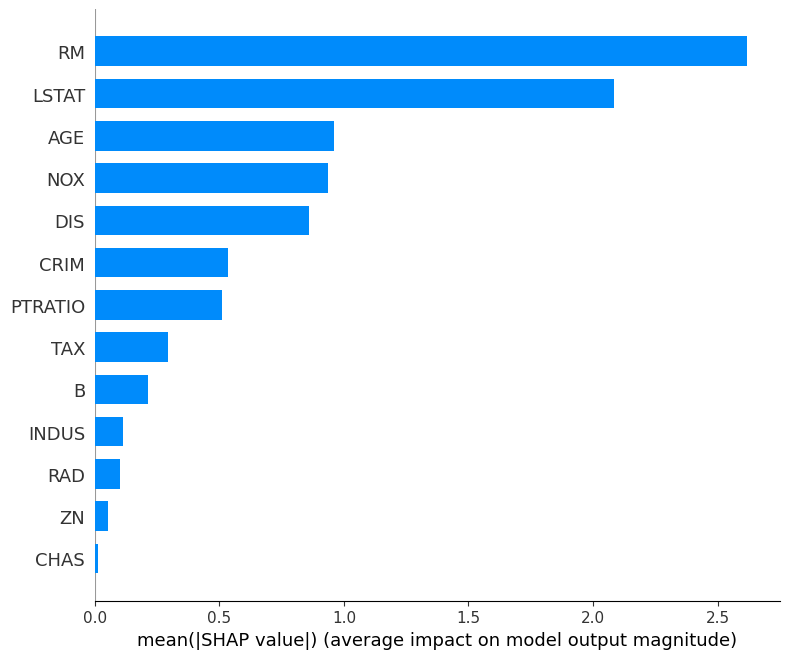

In [54]:
#Gráfico de importancia global
shap.summary_plot(shap_values, X_test,plot_type='bar')


**Interpretación del bar plot de importancia global — caso regresión**

El gráfico muestra el $\text{mean}(|\phi_j|)$ para cada feature sobre todo el test set.  
La variable con mayor barra es la que en promedio produce la mayor desviación del precio predicho respecto al baseline.

**Variables típicamente importantes en Boston Housing:**
- `RM` (habitaciones promedio): mayor cantidad de habitaciones → mayor precio → contribuciones positivas grandes
- `LSTAT` (% bajos ingresos): zonas con alta concentración de bajos ingresos → precio más bajo → contribuciones negativas grandes
- `DIS` (distancia a centros de empleo): afecta el atractivo del vecindario

**Verificación numérica de la importancia:**  
Las últimas celdas (`np.abs(Local_Contrib['RM']).mean()`) calculan manualmente el $\text{mean}(|\phi_j|)$ para confirmar que coincide con la barra del gráfico. Esto es útil para comparar features específicas con precisión numérica.

**Conclusión del análisis con SHAP:**  
La combinación del waterfall (local) y el bar plot (global) ofrece una visión completa del modelo:
- El **bar plot** responde: *¿qué variables importan en general?*
- El **waterfall** responde: *¿por qué el modelo predijo ese valor para esta propiedad concreta?*


mean(|SHAP value|): Media de la suma de los valores absolutos de los shap

In [55]:
import numpy as np
np.abs(Local_Contrib['RM']).mean()

np.float64(2.6199230677486334)

In [56]:
np.abs(Local_Contrib['CHAS']).mean()

np.float64(0.011784625913897602)